# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

/var/folders/_6/sf9_sdv948g9vv933rbbqcgc0000gn/T/ipykernel_54188/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

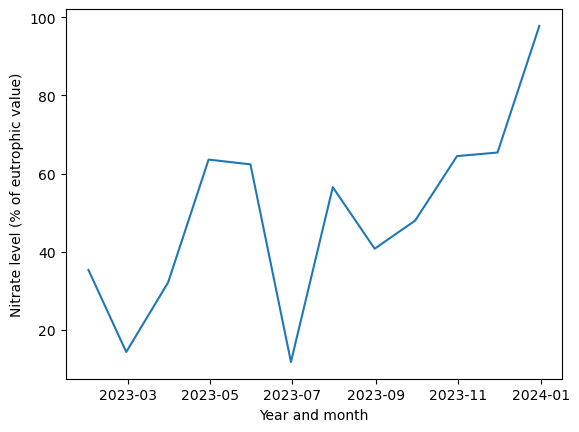

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/var/folders/_6/sf9_sdv948g9vv933rbbqcgc0000gn/T/ipykernel_54188/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

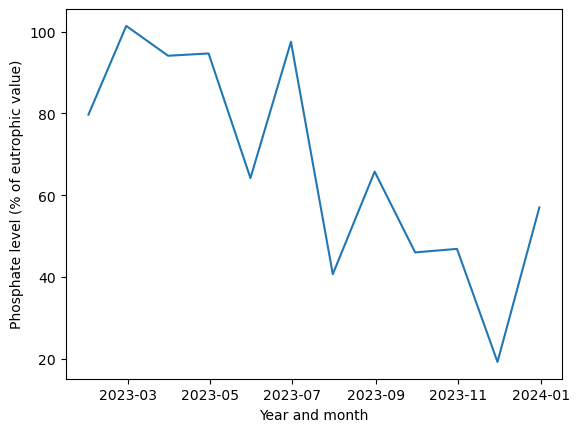

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

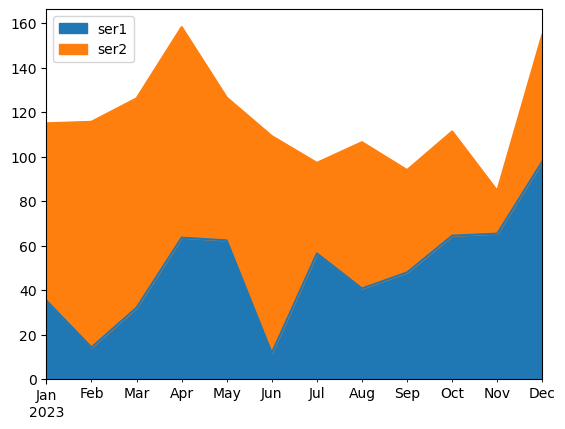

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [5]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nayakganesh007/google-ads-sales-dataset")

print("Path to dataset files:", path)

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/michaelchen/.cache/kagglehub/datasets/nayakganesh007/google-ads-sales-dataset/versions/1


In [6]:
csv_name = os.listdir(path)

In [7]:
df = pd.read_csv(os.path.join(path, csv_name[0]))

In [8]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


In [9]:
df.describe()

,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


In [10]:
df_clean = df.drop(columns=["Ad_ID", "Campaign_Name", "Location", "Keyword"])
df_clean["Cost"] = df_clean["Cost"].replace('[\$,]', '', regex=True).astype(float)

df_clean.info()
# df_clean["Location"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Clicks           2488 non-null   float64
 1   Impressions      2546 non-null   float64
 2   Cost             2503 non-null   float64
 3   Leads            2552 non-null   float64
 4   Conversions      2526 non-null   float64
 5   Conversion Rate  1974 non-null   float64
 6   Sale_Amount      2461 non-null   object 
 7   Ad_Date          2600 non-null   object 
 8   Device           2600 non-null   object 
dtypes: float64(6), object(3)
memory usage: 182.9+ KB


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/_6/sf9_sdv948g9vv933rbbqcgc0000gn/T/ipykernel_54188/1442632240.py:2: SyntaxWarning: invalid escape sequence '\$'
  df_clean["Cost"] = df_clean["Cost"].replace('[\$,]', '', regex=True).astype(float)


In [11]:
s = df_clean["Cost"]
s.apply(type).value_counts()

Cost
<class 'float'>    2600
Name: count, dtype: int64

In [12]:
df_clean["Cost"] = df_clean["Cost"].replace(r'[\$,]', '', regex=True).astype(float)
df_clean["Sale_Amount"] = df_clean["Sale_Amount"].replace(r'[\$,]', '', regex=True).astype(float)

In [13]:
df_clean.head()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Device
0,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-16,desktop
1,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,20-11-2024,mobile
2,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,2024/11/16,Desktop
3,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-26,tablet
4,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,desktop


In [14]:
from datetime import date

# iterate through the Ad_Date column specifically
for dstr in df_clean["Ad_Date"]:
    # pick separator and split
    if "-" in dstr:
        parts = dstr.split("-")
    else:
        parts = dstr.split("/")

    # convert to datetime.date; pattern depends on which part is year
    if len(parts[0]) == 4:              # YYYY-MM-DD or YYYY/MM/DD
        dt = date(int(parts[0]), int(parts[1]), int(parts[2]))
    else:                                # assume DD-MM-YYYY or DD/MM/YYYY
        dt = date(int(parts[2]), int(parts[1]), int(parts[0]))

    df_clean["Ad_Date"] = dt

In [16]:
df_clean["Device"] = df_clean["Device"].str.lower()

In [19]:
df_clean

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Device
0,104.0,4498.0,231.88,14.0,7.0,0.058,1892.0,2024-11-22,desktop
1,173.0,5107.0,216.84,10.0,8.0,0.046,1679.0,2024-11-22,mobile
2,90.0,4544.0,203.66,26.0,9.0,NaN,1624.0,2024-11-22,desktop
3,142.0,3185.0,237.66,17.0,6.0,NaN,1225.0,2024-11-22,tablet
4,156.0,3361.0,195.90,30.0,8.0,NaN,1091.0,2024-11-22,desktop
...,...,...,...,...,...,...,...,...,...
2595,88.0,5344.0,242.07,17.0,9.0,0.054,1418.0,2024-11-22,mobile
2596,154.0,3211.0,248.28,14.0,6.0,0.039,1950.0,2024-11-22,tablet
2597,113.0,3808.0,233.25,18.0,4.0,0.035,1085.0,2024-11-22,desktop
2598,196.0,5853.0,220.13,16.0,7.0,0.036,1558.0,2024-11-22,tablet


In [20]:
num_df = df_clean.select_dtypes(include="number")
num_df.corr()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount
Clicks,1.000000,0.001500,0.034541,0.054291,0.006728,-0.490762,0.036881
Impressions,0.001500,1.000000,0.000671,-0.035502,-0.013960,0.015196,-0.008431
Cost,0.034541,0.000671,1.000000,-0.009370,0.003917,-0.006877,0.010845
Leads,0.054291,-0.035502,-0.009370,1.000000,0.023439,-0.014123,0.011950
Conversions,0.006728,-0.013960,0.003917,0.023439,1.000000,0.641099,-0.003052
Conversion Rate,-0.490762,0.015196,-0.006877,-0.014123,0.641099,1.000000,-0.059127
Sale_Amount,0.036881,-0.008431,0.010845,0.011950,-0.003052,-0.059127,1.000000


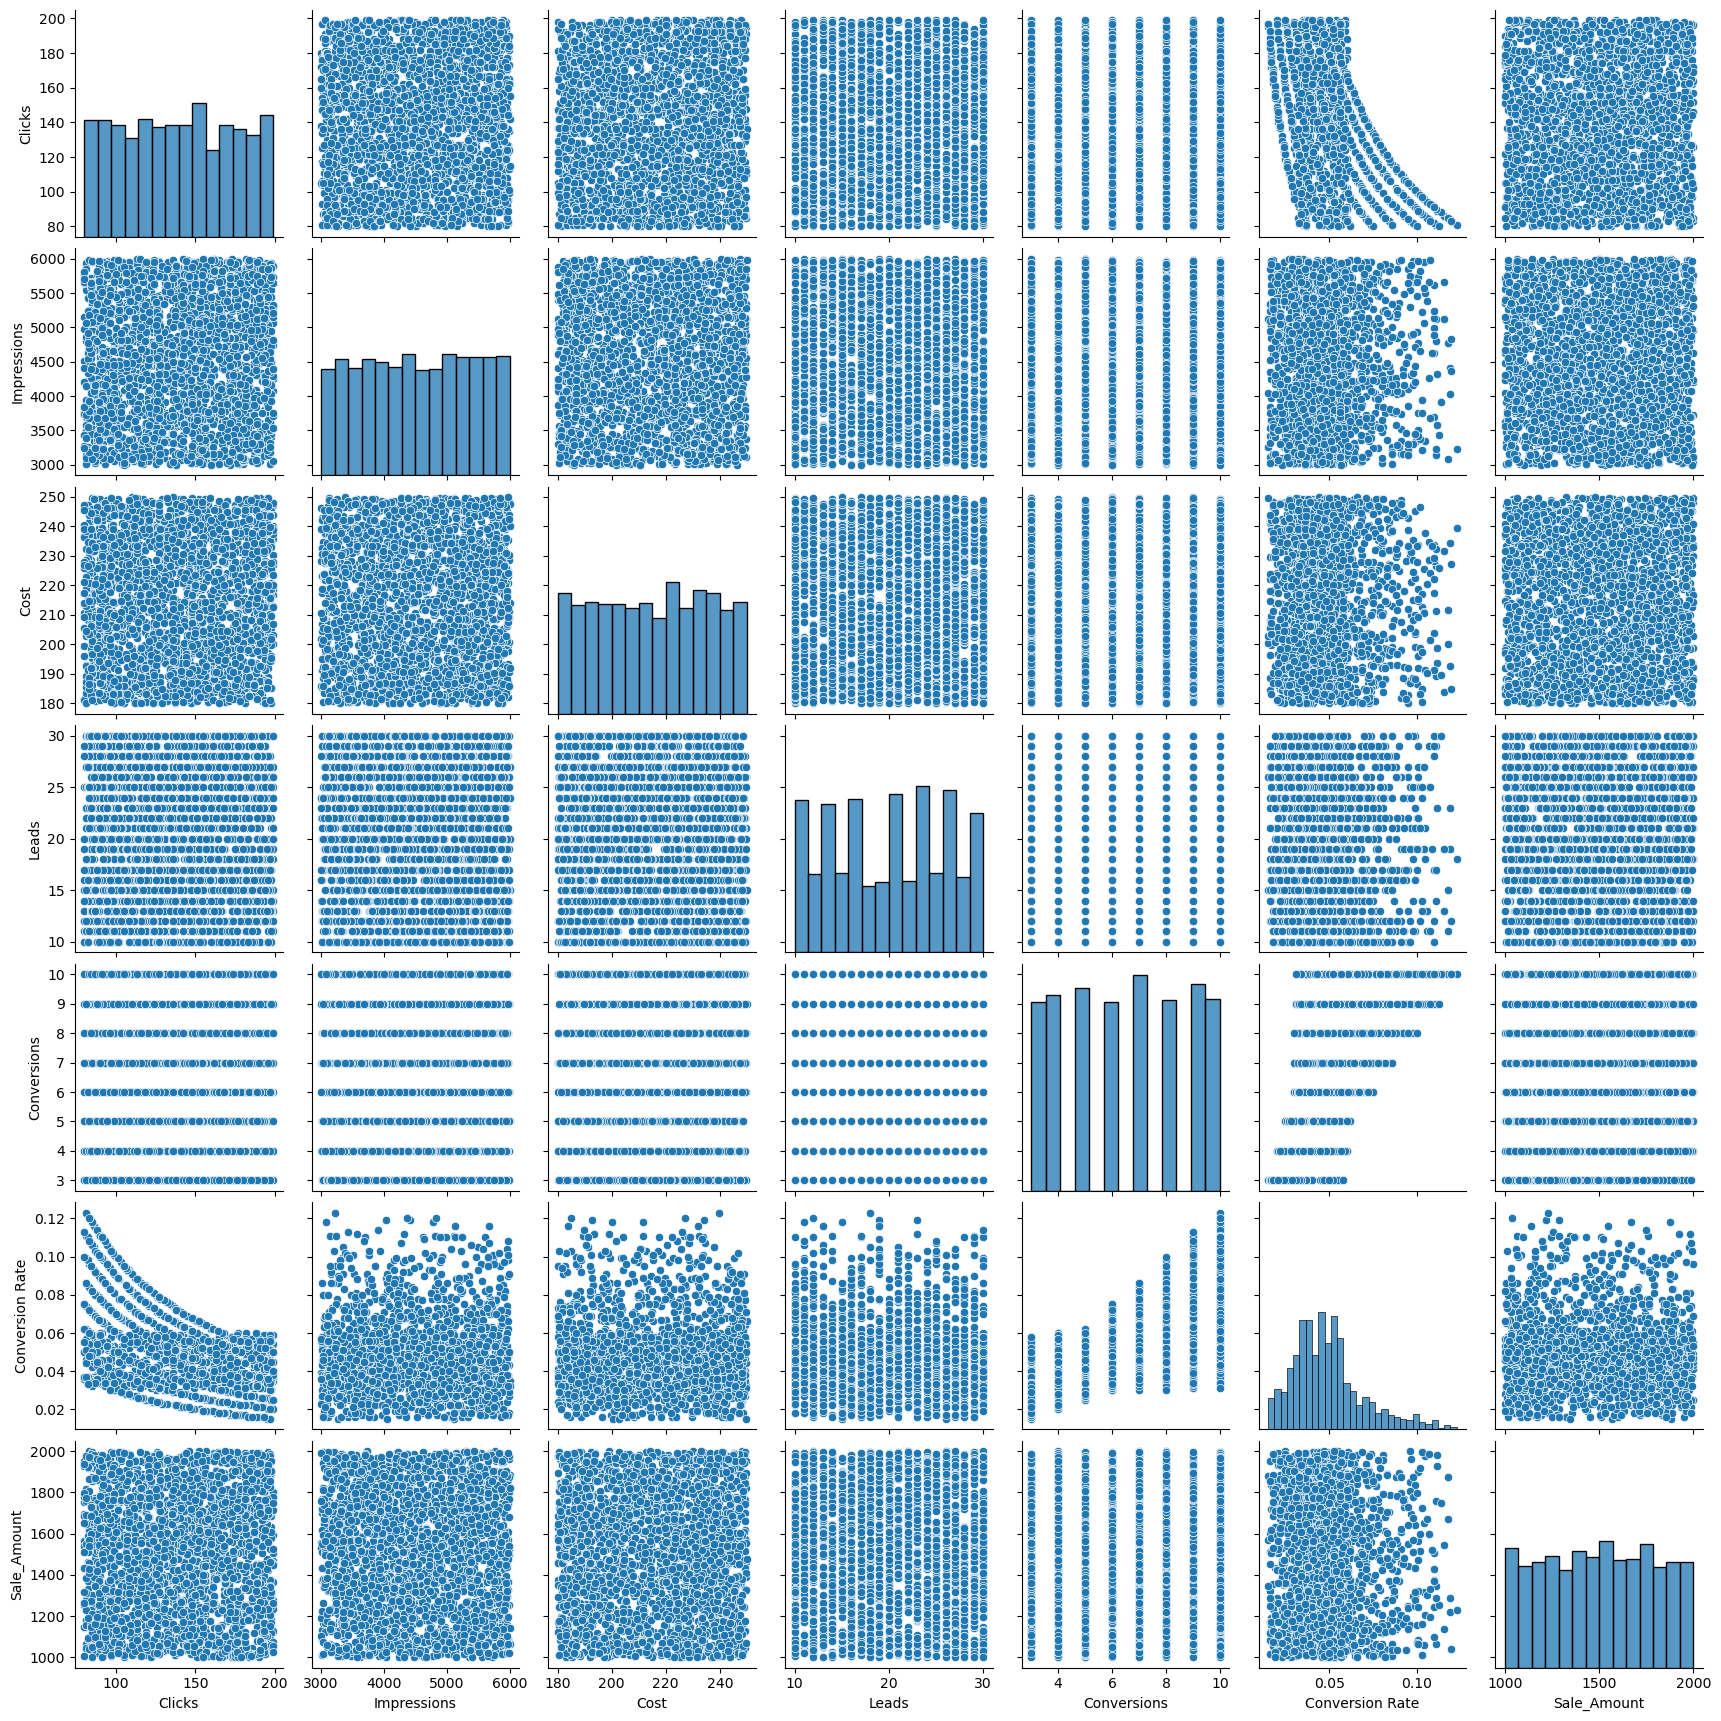

In [22]:
sns.pairplot(df_clean)

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.